# PatchTST RevIN price forecasting -- step 4 + directional loss weight sweep

**Adds an explicit directional loss term to `hf_patchtst_revin_no_volume` (step 4) -- the
best forecasting result on this branch so far (dir acc 0.52-0.55, coherence 0.97-0.99),
and the model currently being walk-forward backtested.** Directional loss was previously
tried on `hf_patchtst_revin_ohlc_global_volume` (step 3b), a variant that already had
*below-chance* directional accuracy (0.46-0.48) before the loss term was added -- so that
result only shows the mechanism doesn't rescue an already-broken volume-included model, not
that it can't help a model that already has real signal. This run closes that gap by
applying the same mechanism to step 4 directly.

**Sweeps `DIR_LOSS_WEIGHT` over `[0.1, 0.5, 1.0, 3.0]`, crossed with both
`channel_attention` settings -- 8 training runs in one pass** (vs. 2 in the plain step-4
notebook -- expect roughly 4x the runtime).

Same directional loss as the step-3b sweep: `-log(sigmoid(DIR_LOSS_SCALE * pred_ret *
true_ret))`, `pred_ret`/`true_ret` measured relative to `close_0` (the same anchor
`directional_accuracy` is measured against), total loss = `mse + DIR_LOSS_WEIGHT *
dir_loss`. `DIR_LOSS_SCALE` stays fixed at `1.0` (not swept this round, same caveat as
step 3b). No volume anywhere -- `N_CHANNELS = 4` (open, high, low, close only), identical
architecture/data/RevIN to step 4.

**Kept identical to `hf_patchtst_revin_no_volume`, for comparability**:
- Data: `steven/data/spy_ohlcv_1h.parquet`, same chronological train/val/test splits.
- `patch_length=7`, `patch_stride=7`, fixed `context_length=MAX_CONTEXT=70`, `HORIZON=3`.
- Model capacity (`d_model=64`, 4 heads, 3 layers) and training hyperparameters
  (`lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x 20,000 windows/epoch).
- No `tanh`/`sigmoid` output bounding.

**Checkpoints saved per `(dir_loss_weight, channel_attention)` combination** to
`steven/outputs/patchtst_revin_novolume_dirloss_w{weight}_channel_attention_{key}_checkpoint.pt`
-- separate filenames from step 4's own checkpoints, so the existing baseline checkpoints
(and their backtest results) aren't overwritten. Same `'target': 'raw_price_revin_no_volume'`
marker in the config, so any winning checkpoint here can go straight into
`steven/src/evaluate_revin.py` unmodified.

**What to look for**: does directional accuracy move meaningfully above the 0.52-0.55 band
step 4 already gets for free, and if so, at what cost to OHLC RMSE and coherence? A weight
where direction improves without RMSE blowing up or coherence collapsing would be the first
real win from loss engineering on this branch; if direction stays flat (or coherence drops)
at every weight, that's strong evidence the mechanism doesn't help here regardless of the
base model's starting point.
</cell id="b5929d82">


## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv


name, memory.total [MiB]
Tesla T4, 15360 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "patchtst_ohlcv_mse"
REPO_DIR = "/content/ECE1508_GenAI"   # absolute path -- see note below

if not os.path.isdir(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    # git -C targets REPO_DIR explicitly rather than `cd X && ...`, so this is correct
    # regardless of the kernel's current working directory when the cell reruns.
    #
    # fetch + checkout {BRANCH} (not just `pull`): REPO_DIR persists across notebook runs
    # within the same Colab VM session, so if an earlier run in this session cloned a
    # DIFFERENT branch (e.g. this VM was previously used for a notebook with an older
    # BRANCH value), a bare `pull` here would just pull more commits onto that stale
    # branch instead of switching -- and the push cell at the bottom would then fail with
    # "src refspec {BRANCH} does not match any", since no local branch by that name would
    # exist to push. Explicitly checking out BRANCH every time this cell runs avoids that.
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} checkout {BRANCH}
    !git -C {REPO_DIR} pull origin {BRANCH}

# Absolute path, not "ECE1508_GenAI": os.path.isdir("ECE1508_GenAI") above is checked
# relative to the CURRENT working directory -- on a second run of this cell (after the
# %cd below already moved the kernel into /content/ECE1508_GenAI), that relative check
# looks for /content/ECE1508_GenAI/ECE1508_GenAI, finds nothing, and silently clones a
# second, nested copy of the repo inside the first one instead of pulling it.
%cd {REPO_DIR}


Cloning into '/content/ECE1508_GenAI'...
remote: Enumerating objects: 1519, done.
remote: Counting objects: 100% (1031/1031), done.
remote: Compressing objects: 100% (737/737), done.
remote: Total 1519 (delta 528), reused 779 (delta 293), pack-reused 488 (from 1)
Receiving objects: 100% (1519/1519), 54.08 MiB | 15.39 MiB/s, done.
Resolving deltas: 100% (729/729), done.
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.2 MB/s eta 0:00:00


In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

`EXPERIMENT` describes *this run* -- it's what gets echoed into each output JSON's
`"experiment"` block and is the thing to paste into `docs/experiments.md`'s row when logging
the result, so the doc and the actual run config can't drift apart. Update `name`/`description`
each time this notebook is repurposed for a different target/volume/loss variant (per the
experiment ladder: fused-head parity check -> drop volume -> raw-price+volume ->
raw-price-no-volume -> head comparison).


In [6]:
import sys, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import build_dataset, WindowSampler, MAX_CONTEXT, HORIZON
from src.models.patchtst_hf import (
    RevIN, PatchTSTOHLCVRevIN, OHLC_COLS, N_CHANNELS, CLOSE_IDX,
    build_model as _build_model_shared,
)
# No import of weighted_mse_loss/unpack_y/reconstruct_volume -- volume is dropped
# entirely in this run (see intro markdown), so none of the volume-handling helpers apply.
# RevIN/PatchTSTOHLCVRevIN/OHLC_COLS/N_CHANNELS/CLOSE_IDX now come from
# src/models/patchtst_hf.py (not defined inline here anymore) -- extracted into an
# importable module so evaluate.py can reconstruct the exact same architecture from a
# saved checkpoint (see the checkpoint-saving cell in the training loop below).

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'
CKPT_DIR = 'steven/outputs'


# -- Describes this run -- echoed into every output JSON and comparison_metrics/ filename.
# "name" -> comparison_metrics/{name}-w{dir_loss_weight}-channel_attention_{false,true}.json
EXPERIMENT = {
    "name": "hf_patchtst_revin_no_volume_dirloss",
    "description": (
        "hf_patchtst_revin_no_volume (step 4) + an explicit directional loss term, swept "
        "over DIR_LOSS_WEIGHT x channel_attention. Step 4 already has above-chance "
        "directional accuracy on its own (0.52-0.55) -- this tests whether the directional "
        "loss mechanism (previously only tried on step 3b, a below-chance volume-included "
        "variant) can push it higher when applied to a model that already has real signal."
    ),
    "target": "raw_price_revin_no_volume",
    "include_volume": False,
    "loss_weights": {"note": "mse + dir_loss_weight * dir_loss, dir_loss_weight swept this run"},
}

# -- Both settings are trained in one pass -- see the training loop below.
CHANNEL_ATTENTION_SETTINGS = [False, True]

# -- Directional loss hyperparameters. DIR_LOSS_WEIGHT is swept this round (see intro
# markdown); DIR_LOSS_SCALE stays fixed -- untuned, not part of this sweep (same caveat
# as the step-3b sweep this is ported from).
DIR_LOSS_WEIGHTS = [0.1, 0.5, 1.0, 3.0]
DIR_LOSS_SCALE   = 1.0
EXPERIMENT['dir_loss_weights_swept'] = DIR_LOSS_WEIGHTS
EXPERIMENT['dir_loss_scale'] = DIR_LOSS_SCALE

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block, same
# as every other notebook in this family, for comparable model capacity.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- one trading day, non-overlapping.
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- same as every other notebook in this family.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control -- reset again per (weight, channel_attention) combination in the
# training loop below, so every one of the 8 runs gets identical weight init/dropout draws.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'EXPERIMENT = {EXPERIMENT}')
print(f'SEED = {SEED}, DIR_LOSS_WEIGHTS = {DIR_LOSS_WEIGHTS}, CHANNEL_ATTENTION_SETTINGS = {CHANNEL_ATTENTION_SETTINGS}')
print(f'Total runs this pass: {len(DIR_LOSS_WEIGHTS) * len(CHANNEL_ATTENTION_SETTINGS)}')


Device: cuda
EXPERIMENT = {'name': 'hf_patchtst_revin_no_volume_dirloss', 'description': 'hf_patchtst_revin_no_volume (step 4) + an explicit directional loss term, swept over DIR_LOSS_WEIGHT x channel_attention. Step 4 already has above-chance directional accuracy on its own (0.52-0.55) -- this tests whether the directional loss mechanism (previously only tried on step 3b, a below-chance volume-included variant) can push it higher when applied to a model that already has real signal.', 'target': 'raw_price_revin_no_volume', 'include_volume': False, 'loss_weights': {'note': 'mse + dir_loss_weight * dir_loss, dir_loss_weight swept this run'}, 'dir_loss_weights_swept': [0.1, 0.5, 1.0, 3.0], 'dir_loss_scale': 1.0}
SEED = 0, DIR_LOSS_WEIGHTS = [0.1, 0.5, 1.0, 3.0], CHANNEL_ATTENTION_SETTINGS = [False, True]
Total runs this pass: 8


## RevIN + model

**`RevIN`**: a real implementation (mean/std + learnable `affine_weight`/`affine_bias`),
not HF `PatchTSTModel`'s built-in scaler. `fit()` computes per-window, per-channel mean/std
from the **context** only; the same stored stats are reused to normalize the true future
OHLC (for the loss) and denormalize the model's predictions (for evaluation). Covers all
`N_CHANNELS=4` channels here -- no split logic needed, since volume isn't in the picture at
all (unlike step 3's `hf_patchtst_revin_ohlc_global_volume`, which had to route volume
around RevIN separately).

**`PatchTSTOHLCVRevIN`**: `PatchTSTModel` backbone (`scaling=None` -- RevIN is applied
externally instead) + the same fused/flattened head design used throughout this project --
**no `tanh`/`sigmoid` bounding** (RevIN-normalized values don't have the physical cap
log-returns do).

**Now imported from `steven/src/models/patchtst_hf.py`, not defined inline** -- extracted so `evaluate.py` can reconstruct this exact class from a saved checkpoint. The cell below just wraps the shared `build_model()` with this notebook's own hyperparameter constants.


In [7]:
def build_model(channel_attention: bool) -> PatchTSTOHLCVRevIN:
    """Thin wrapper around src.models.patchtst_hf.build_model, applying this notebook's
    own hyperparameter constants -- RevIN/PatchTSTOHLCVRevIN themselves are now defined
    in that shared module (see imports cell), not inline here."""
    return _build_model_shared(
        channel_attention,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        context_length=MAX_CONTEXT,
    )


## Data

Reuses `build_dataset`/`WindowSampler` from `steven/src/data_pipeline.py` for the
chronological train/val/test split boundaries and valid-start-index logic, but builds
windows directly from **raw OHLC price** (`df[OHLC_COLS]`) -- no volume column at all this
time, no `build_window()`/return-decomposition, no reconstruction needed at evaluation time
(the model's denormalized output is already real price).

Built **once** here, shared across both `channel_attention` settings in the training loop
below, same as every other notebook in this family.


In [8]:
df, bounds, stats = build_dataset(DATA_PATH)
ohlc = df[OHLC_COLS].to_numpy(dtype=np.float32)   # (N, 4) -- raw price, no normalization yet, no volume

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextOHLCDataset(Dataset):
    """Every window uses the full MAX_CONTEXT (70 bars); target is the next HORIZON (3)
    bars, both as raw OHLC -- no padding handling needed since ctx_bars == MAX_CONTEXT
    exactly (same fixed-context simplification as every other notebook in this family)."""
    def __init__(self, ohlc: np.ndarray, start_indices: np.ndarray):
        self.ohlc = ohlc
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        s = int(self.start_indices[i])
        context = self.ohlc[s : s + MAX_CONTEXT]
        target  = self.ohlc[s + MAX_CONTEXT : s + MAX_CONTEXT + HORIZON]
        return {
            'past_values': torch.from_numpy(context),
            'future_values': torch.from_numpy(target),
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'future_values': torch.stack([b['future_values'] for b in batch]),
    }


train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
test_starts_full   = test_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')
print(f'Valid test starts (ctx=70) : {len(test_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextOHLCDataset(ohlc, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextOHLCDataset(ohlc, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)


Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469
Valid train starts (ctx=70): 20,970
Valid val starts (ctx=70)  : 3,423
Valid test starts (ctx=70) : 2,397


## Training + evaluation

Trains one model per `(DIR_LOSS_WEIGHT, channel_attention)` combination -- 8 total this
pass -- evaluates each on the same fixed test set, and writes one JSON per combination to
`steven/comparison_metrics/`, plus a checkpoint per combination to `steven/outputs/`.

**Loss**: `mse + dir_loss_weight * dir_loss`, `dir_loss_weight` taken from the outer sweep
loop below. `mse` is plain MSE in RevIN-normalized OHLC space (same as step 4); `dir_loss`
is computed in real price space (predicted close denormalized via `model.revin`, compared
against `close_0`) so it directly targets the same quantity `directional_accuracy` is
measured against.

**Evaluation** reports OHLC MAE/RMSE, per-horizon-bar directional accuracy, and coherence
rate -- same methodology as step 4, so each of the 8 runs is directly comparable to
`hf_patchtst_revin_no_volume` (no directional loss) and to each other.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers in `steven/outputs/metrics.json`, not his "overall" (mixed-length) numbers.
</cell id="f7e860b4">



training w0.1-channel_attention_false
epoch  1/20  train_loss=1.024607 (mse=0.905257, dir=1.193500)  val_loss=2.047747 (mse=1.497343, dir=5.504033)
epoch  2/20  train_loss=0.465258 (mse=0.379543, dir=0.857144)  val_loss=0.502790 (mse=0.328905, dir=1.738850)
epoch  3/20  train_loss=0.414120 (mse=0.332897, dir=0.812223)  val_loss=0.412569 (mse=0.261995, dir=1.505743)
epoch  4/20  train_loss=0.389269 (mse=0.309206, dir=0.800632)  val_loss=0.444123 (mse=0.290654, dir=1.534695)
epoch  5/20  train_loss=0.390642 (mse=0.308266, dir=0.823760)  val_loss=0.339252 (mse=0.229938, dir=1.093138)
epoch  6/20  train_loss=0.361132 (mse=0.282588, dir=0.785448)  val_loss=0.324645 (mse=0.219029, dir=1.056159)
epoch  7/20  train_loss=0.350170 (mse=0.270656, dir=0.795141)  val_loss=0.325944 (mse=0.221324, dir=1.046196)
epoch  8/20  train_loss=0.338316 (mse=0.260672, dir=0.776442)  val_loss=0.349937 (mse=0.224641, dir=1.252957)
epoch  9/20  train_loss=0.329717 (mse=0.251904, dir=0.778130)  val_loss=0.332899 

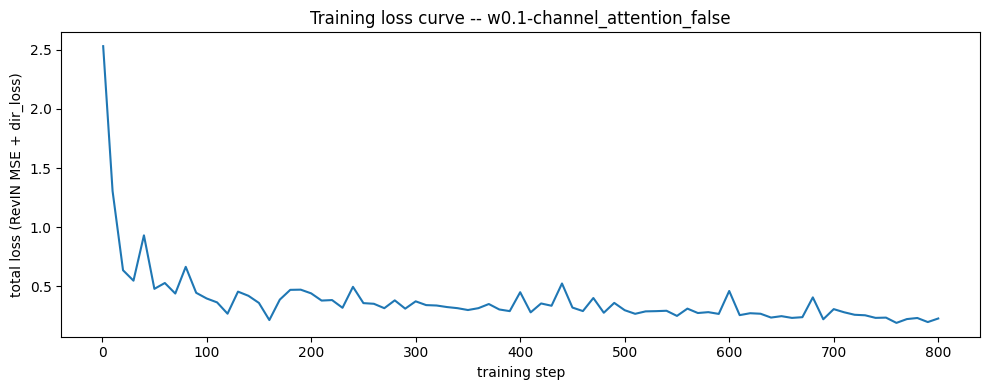

  OHLC MAE / RMSE     : 1.8656 / 3.1253
  dir acc per bar     : 0.5236 / 0.5382 / 0.5499
  coherence rate      : 0.9412  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.1-channel_attention_false.json

training w0.1-channel_attention_true
epoch  1/20  train_loss=0.931777 (mse=0.817325, dir=1.144522)  val_loss=2.191624 (mse=1.609091, dir=5.825333)
epoch  2/20  train_loss=0.457566 (mse=0.372473, dir=0.850932)  val_loss=0.545121 (mse=0.354291, dir=1.908294)
epoch  3/20  train_loss=0.421738 (mse=0.338091, dir=0.836469)  val_loss=0.399514 (mse=0.266450, dir=1.330644)
epoch  4/20  train_loss=0.399778 (mse=0.318869, dir=0.809092)  val_loss=0.453197 (mse=0.306908, dir=1.462884)
epoch  5/20  train_loss=0.400678 (mse=0.318148, dir=0.825295)  val_loss=0.349973 (mse=0.237220, dir=1.127537)
epoch  6/20  train_loss=0.370173 (mse=0.290147, dir=0.800254)  val_loss=0.329672 (mse=0.222570, dir=1.071022)
epoch  7/20  train_loss=0.35501

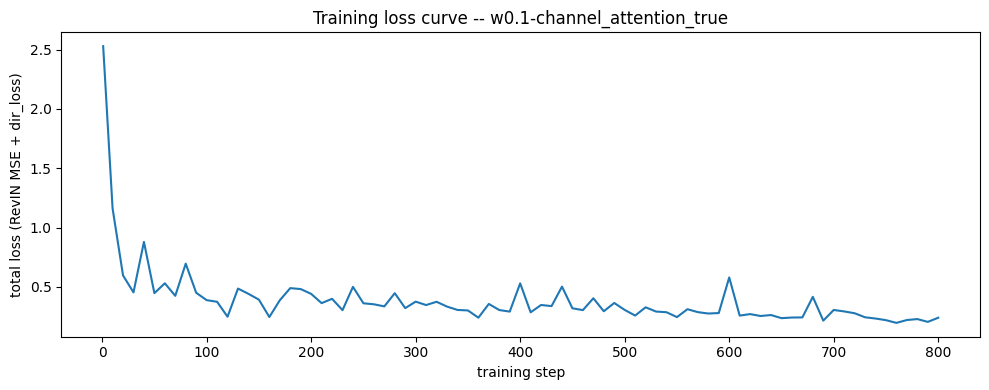

  OHLC MAE / RMSE     : 2.2407 / 3.4010
  dir acc per bar     : 0.5265 / 0.5419 / 0.5524
  coherence rate      : 0.9808  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.1-channel_attention_true.json

training w0.5-channel_attention_false
epoch  1/20  train_loss=1.536607 (mse=0.935524, dir=1.202165)  val_loss=4.381285 (mse=1.554682, dir=5.653206)
epoch  2/20  train_loss=0.854905 (mse=0.410967, dir=0.887876)  val_loss=1.052576 (mse=0.312828, dir=1.479496)
epoch  3/20  train_loss=0.762127 (mse=0.345710, dir=0.832833)  val_loss=1.199983 (mse=0.281336, dir=1.837296)
epoch  4/20  train_loss=0.724123 (mse=0.316823, dir=0.814602)  val_loss=1.015517 (mse=0.266857, dir=1.497322)
epoch  5/20  train_loss=0.726673 (mse=0.314753, dir=0.823840)  val_loss=1.202948 (mse=0.286180, dir=1.833537)
epoch  6/20  train_loss=0.680589 (mse=0.289247, dir=0.782685)  val_loss=0.781623 (mse=0.229045, dir=1.105156)
epoch  7/20  train_loss=0.68750

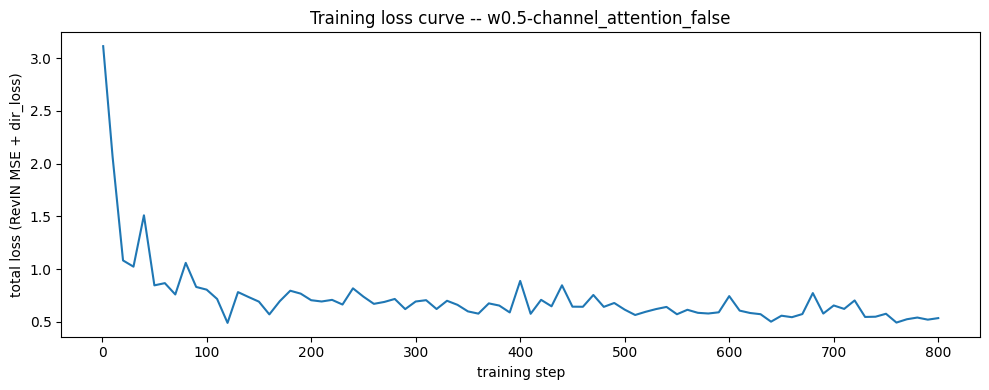

  OHLC MAE / RMSE     : 1.8601 / 3.1253
  dir acc per bar     : 0.5065 / 0.5219 / 0.5273
  coherence rate      : 0.7939  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.5-channel_attention_false.json

training w0.5-channel_attention_true
epoch  1/20  train_loss=1.425819 (mse=0.851651, dir=1.148335)  val_loss=4.492520 (mse=1.605552, dir=5.773936)
epoch  2/20  train_loss=0.843191 (mse=0.401791, dir=0.882800)  val_loss=1.136590 (mse=0.343464, dir=1.586253)
epoch  3/20  train_loss=0.790486 (mse=0.356364, dir=0.868244)  val_loss=1.183955 (mse=0.289128, dir=1.789655)
epoch  4/20  train_loss=0.732613 (mse=0.324146, dir=0.816935)  val_loss=0.910934 (mse=0.271367, dir=1.279134)
epoch  5/20  train_loss=0.736710 (mse=0.324600, dir=0.824221)  val_loss=0.856572 (mse=0.252588, dir=1.207968)
epoch  6/20  train_loss=0.692977 (mse=0.296165, dir=0.793624)  val_loss=0.964499 (mse=0.255919, dir=1.417159)
epoch  7/20  train_loss=0.68822

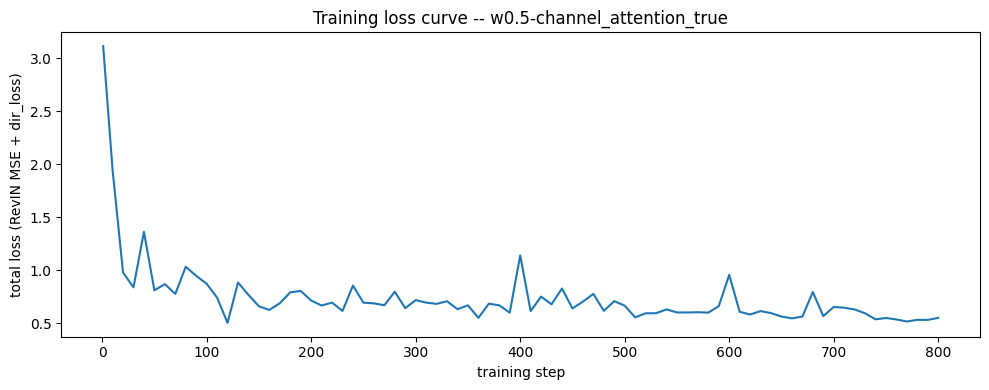

  OHLC MAE / RMSE     : 2.0371 / 3.2380
  dir acc per bar     : 0.5198 / 0.5382 / 0.5490
  coherence rate      : 0.9712  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.5-channel_attention_true.json

training w1.0-channel_attention_false
epoch  1/20  train_loss=2.183209 (mse=0.968582, dir=1.214627)  val_loss=7.293848 (mse=1.582904, dir=5.710944)
epoch  2/20  train_loss=1.319072 (mse=0.424271, dir=0.894802)  val_loss=2.136598 (mse=0.368872, dir=1.767726)
epoch  3/20  train_loss=1.197030 (mse=0.359103, dir=0.837927)  val_loss=2.454155 (mse=0.311459, dir=2.142696)
epoch  4/20  train_loss=1.147716 (mse=0.323538, dir=0.824178)  val_loss=1.751386 (mse=0.270293, dir=1.481093)
epoch  5/20  train_loss=1.132949 (mse=0.318307, dir=0.814642)  val_loss=2.690660 (mse=0.375867, dir=2.314793)
epoch  6/20  train_loss=1.086591 (mse=0.296434, dir=0.790157)  val_loss=1.358384 (mse=0.230932, dir=1.127452)
epoch  7/20  train_loss=1.08201

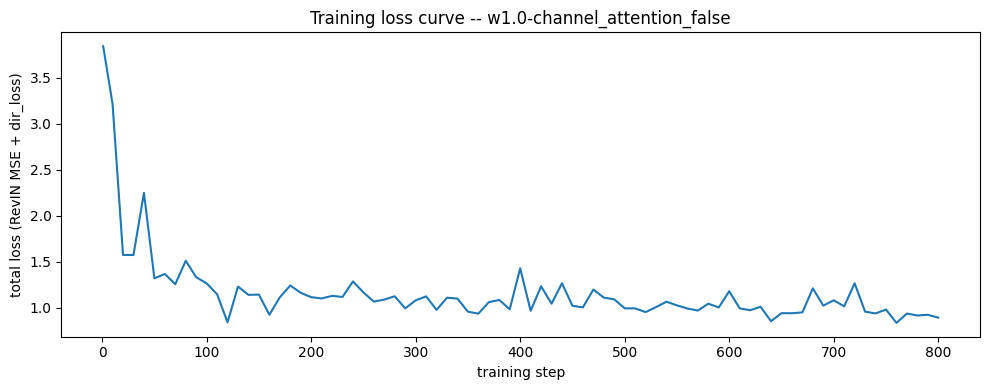

  OHLC MAE / RMSE     : 1.8642 / 3.1285
  dir acc per bar     : 0.5140 / 0.5186 / 0.5365
  coherence rate      : 0.8798  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w1.0-channel_attention_false.json

training w1.0-channel_attention_true
epoch  1/20  train_loss=2.074807 (mse=0.909973, dir=1.164834)  val_loss=7.692939 (mse=1.685356, dir=6.007583)
epoch  2/20  train_loss=1.281040 (mse=0.408923, dir=0.872118)  val_loss=2.491018 (mse=0.387475, dir=2.103543)
epoch  3/20  train_loss=1.257504 (mse=0.376782, dir=0.880722)  val_loss=2.496604 (mse=0.327825, dir=2.168778)
epoch  4/20  train_loss=1.169436 (mse=0.335038, dir=0.834398)  val_loss=2.229624 (mse=0.321204, dir=1.908420)
epoch  5/20  train_loss=1.152724 (mse=0.325856, dir=0.826869)  val_loss=1.438874 (mse=0.249714, dir=1.189160)
epoch  6/20  train_loss=1.088604 (mse=0.298410, dir=0.790194)  val_loss=1.798233 (mse=0.272589, dir=1.525644)
epoch  7/20  train_loss=1.09433

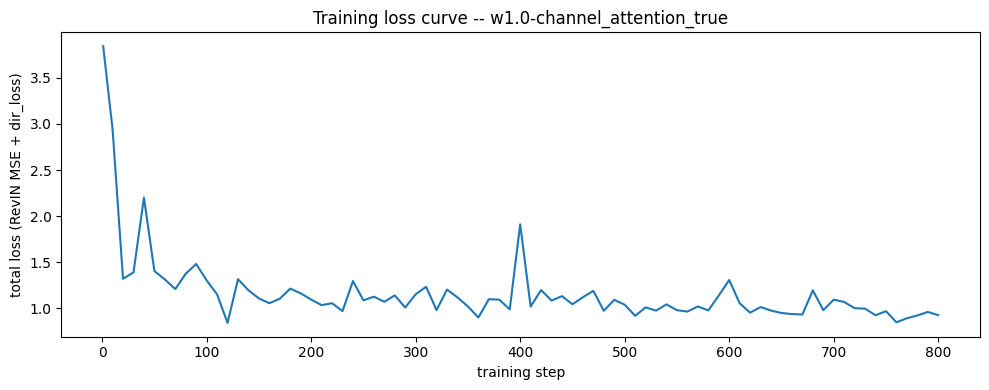

  OHLC MAE / RMSE     : 1.8101 / 3.0628
  dir acc per bar     : 0.5173 / 0.5223 / 0.5336
  coherence rate      : 0.7972  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w1.0-channel_attention_true.json

training w3.0-channel_attention_false
epoch  1/20  train_loss=4.771601 (mse=1.071421, dir=1.233393)  val_loss=18.054685 (mse=1.554910, dir=5.499925)
epoch  2/20  train_loss=3.433821 (mse=0.502053, dir=0.977256)  val_loss=7.192943 (mse=0.472717, dir=2.240075)
epoch  3/20  train_loss=2.950705 (mse=0.378546, dir=0.857386)  val_loss=4.854105 (mse=0.323588, dir=1.510172)
epoch  4/20  train_loss=2.830022 (mse=0.340894, dir=0.829709)  val_loss=4.752445 (mse=0.274613, dir=1.492611)
epoch  5/20  train_loss=2.825542 (mse=0.341065, dir=0.828159)  val_loss=6.589307 (mse=0.352794, dir=2.078838)
epoch  6/20  train_loss=2.738223 (mse=0.321366, dir=0.805619)  val_loss=4.624660 (mse=0.285156, dir=1.446501)
epoch  7/20  train_loss=2.7835

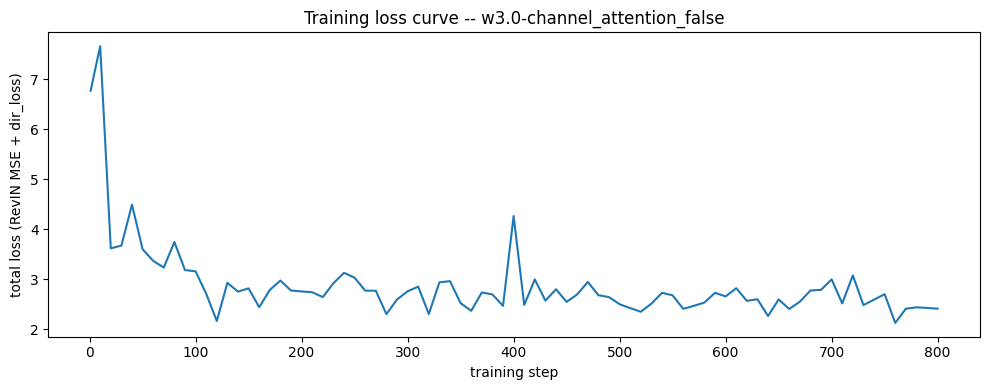

  OHLC MAE / RMSE     : 1.8004 / 3.1027
  dir acc per bar     : 0.4827 / 0.4764 / 0.4902
  coherence rate      : 0.7764  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w3.0-channel_attention_false.json

training w3.0-channel_attention_true
epoch  1/20  train_loss=4.621688 (mse=1.004381, dir=1.205769)  val_loss=20.338787 (mse=1.788363, dir=6.183475)
epoch  2/20  train_loss=3.239703 (mse=0.466944, dir=0.924253)  val_loss=8.434961 (mse=0.484421, dir=2.650180)
epoch  3/20  train_loss=3.132087 (mse=0.405960, dir=0.908709)  val_loss=5.007573 (mse=0.331593, dir=1.558660)
epoch  4/20  train_loss=2.836553 (mse=0.350117, dir=0.828812)  val_loss=6.408648 (mse=0.341140, dir=2.022503)
epoch  5/20  train_loss=2.846436 (mse=0.342456, dir=0.834660)  val_loss=4.448328 (mse=0.272929, dir=1.391800)
epoch  6/20  train_loss=2.706989 (mse=0.312128, dir=0.798287)  val_loss=6.102222 (mse=0.334112, dir=1.922704)
epoch  7/20  train_loss=2.7629

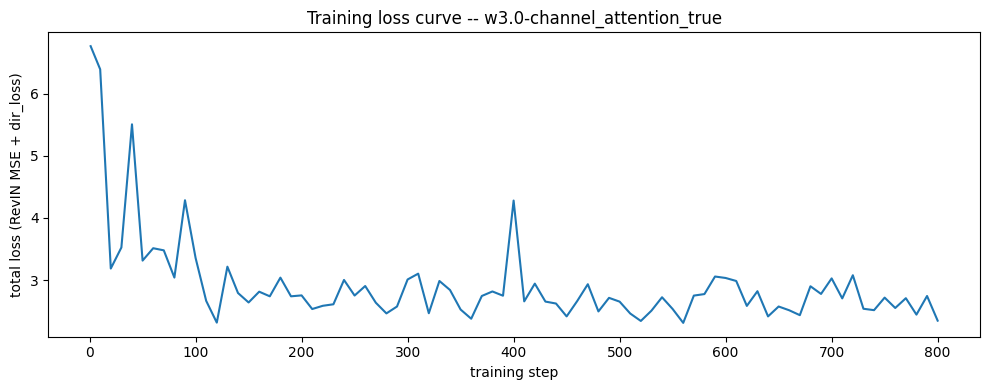

  OHLC MAE / RMSE     : 2.2657 / 3.7407
  dir acc per bar     : 0.5035 / 0.4827 / 0.4856
  coherence rate      : 0.9145  (step 4 baseline: 0.9741 False / 0.9875 True)
  wrote steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w3.0-channel_attention_true.json


done -- 8 runs completed.


In [10]:
def directional_loss(pred_close_real: torch.Tensor, true_close_real: torch.Tensor,
                      close_0: torch.Tensor, scale: float) -> torch.Tensor:
    """Soft, differentiable penalty for predicted/true close-return sign disagreement.
    pred_ret/true_ret are both measured relative to close_0 -- the same anchor
    directional_accuracy uses at eval time. pred_ret*true_ret > 0 (same sign) -> small
    loss; < 0 (opposite sign) -> large loss. `scale` rescales the product into the
    sigmoid's sensitive range before -log(sigmoid(.)) -- see intro markdown."""
    pred_ret = pred_close_real - close_0.unsqueeze(-1)
    true_ret = true_close_real - close_0.unsqueeze(-1)
    agreement = pred_ret * true_ret * scale
    return -F.logsigmoid(agreement).mean()


def run_epoch(model, loader, optimizer, device, dir_loss_weight: float, train: bool,
              loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, mse_total, dir_total, n = 0.0, 0.0, 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        future_values = batch['future_values'].to(device)

        with torch.set_grad_enabled(train):
            pred_norm = model(past_values)
            # RevIN.fit() was just called inside model() using this batch's context, so
            # model.revin.normalize() here uses the matching context-derived stats to put
            # the true target in the same normalized space the loss is computed in.
            true_norm = model.revin.normalize(future_values)
            mse = F.mse_loss(pred_norm, true_norm)

            # Directional term, computed in real price space (see directional_loss above).
            pred_price_real = model.revin.denormalize(pred_norm)
            pred_close_real = pred_price_real[:, :, CLOSE_IDX]
            true_close_real = future_values[:, :, CLOSE_IDX]
            close_0 = past_values[:, -1, CLOSE_IDX]
            dir_loss = directional_loss(pred_close_real, true_close_real, close_0, DIR_LOSS_SCALE)

            loss = mse + dir_loss_weight * dir_loss

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = past_values.shape[0]
        total += loss.item() * bs
        mse_total += mse.item() * bs
        dir_total += dir_loss.item() * bs
        n += bs
    return {'loss': total / n, 'mse': mse_total / n, 'dir_loss': dir_total / n}


def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


def evaluate(model) -> dict:
    model.eval()
    all_true, all_pred, all_close0 = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            pv = batch['past_values'].to(DEVICE)
            fv = batch['future_values'].to(DEVICE)
            pred_norm = model(pv)
            pred_price = model.revin.denormalize(pred_norm)   # back to real price -- no reconstruct_prices needed
            all_true.append(fv.cpu().numpy())
            all_pred.append(pred_price.cpu().numpy())
            all_close0.append(pv[:, -1, CLOSE_IDX].cpu().numpy())   # last context bar's real close

    true_ohlc = np.concatenate(all_true)     # (n, 3, 4) real [open,high,low,close]
    pred_ohlc = np.concatenate(all_pred)     # (n, 3, 4) predicted
    close_0 = np.concatenate(all_close0)     # (n,)
    n = len(true_ohlc)

    ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

    true_close_sign = np.sign(true_ohlc[:, :, CLOSE_IDX] - close_0[:, None])
    pred_close_sign = np.sign(pred_ohlc[:, :, CLOSE_IDX] - close_0[:, None])
    dir_acc = (true_close_sign == pred_close_sign).mean(axis=0)

    # Coherence check -- see markdown above.
    coherent_up = (pred_close_sign > 0).all(axis=1)
    coherent_down = (pred_close_sign < 0).all(axis=1)
    coherence_rate = float((coherent_up | coherent_down).mean())

    return {
        'n_windows': n,
        'ohlc_mae': ohlc_mae,
        'ohlc_rmse': ohlc_rmse,
        'directional_accuracy': dir_acc.tolist(),
        'coherence_rate': coherence_rate,
    }


os.makedirs('steven/comparison_metrics', exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
results = {}

for dir_loss_weight in DIR_LOSS_WEIGHTS:
    for channel_attention in CHANNEL_ATTENTION_SETTINGS:
        ca_key = f'channel_attention_{str(channel_attention).lower()}'
        setting_key = f'w{dir_loss_weight}-{ca_key}'
        print(f'\n{"="*70}\ntraining {setting_key}\n{"="*70}')

        # Reset the seed per combination so every one of the 8 runs gets identical weight
        # init/dropout draws -- data order is already independent of global RNG state
        # (np.random.default_rng(SEED+epoch) below), but model init/dropout use torch's
        # global RNG, which would otherwise keep advancing across the sweep.
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        model = build_model(channel_attention).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        # Saved on every val-loss improvement (val loss = total loss, mse + weighted
        # dir_loss, same quantity training optimizes) -- separate filename per combination
        # so step 4's own baseline checkpoints (and their backtest results) aren't touched.
        # Still carries 'target': 'raw_price_revin_no_volume' so evaluate_revin.py can
        # load any of these checkpoints unmodified.
        ckpt_path = f'{CKPT_DIR}/patchtst_revin_novolume_dirloss_w{dir_loss_weight}_{ca_key}_checkpoint.pt'

        loss_history = []
        step_holder = [0]
        best_val_loss = float('inf')

        for epoch in range(MAX_EPOCHS):
            train_rng = np.random.default_rng(SEED + epoch)
            n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
            train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
            train_ds = FixedContextOHLCDataset(ohlc, train_starts)
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

            train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, dir_loss_weight, train=True,
                                       loss_history=loss_history, step_holder=step_holder)
            val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, dir_loss_weight, train=False)

            print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
                  f'train_loss={train_metrics["loss"]:.6f} (mse={train_metrics["mse"]:.6f}, dir={train_metrics["dir_loss"]:.6f})  '
                  f'val_loss={val_metrics["loss"]:.6f} (mse={val_metrics["mse"]:.6f}, dir={val_metrics["dir_loss"]:.6f})')

            if val_metrics['loss'] < best_val_loss:
                best_val_loss = val_metrics['loss']
                torch.save({
                    'model_state': model.state_dict(),
                    'config': {
                        'model': {
                            'channel_attention': channel_attention,
                            'd_model': D_MODEL,
                            'num_attention_heads': NUM_HEADS,
                            'num_hidden_layers': NUM_LAYERS,
                            'dropout': DROPOUT,
                            'head_dropout': HEAD_DROPOUT,
                            'patch_length': PATCH_LEN,
                            'patch_stride': PATCH_STRIDE,
                        },
                        'context_length': MAX_CONTEXT,
                        'data_path': DATA_PATH,
                        'seed': SEED,
                        'target': 'raw_price_revin_no_volume',
                        'dir_loss_weight': dir_loss_weight,
                        'dir_loss_scale': DIR_LOSS_SCALE,
                    },
                }, ckpt_path)

        print(f'done ({setting_key}). best val_loss={best_val_loss:.6f}, checkpoint={ckpt_path}')

        fig, ax = plt.subplots(figsize=(10, 4))
        steps, losses = zip(*loss_history)
        ax.plot(steps, losses)
        ax.set_xlabel('training step')
        ax.set_ylabel('total loss (RevIN MSE + dir_loss)')
        ax.set_title(f'Training loss curve -- {setting_key}')
        plt.tight_layout()
        plt.show()

        eval_metrics = evaluate(model)
        print(f'  OHLC MAE / RMSE     : {eval_metrics["ohlc_mae"]:.4f} / {eval_metrics["ohlc_rmse"]:.4f}')
        dir_acc = eval_metrics['directional_accuracy']
        print(f'  dir acc per bar     : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')
        print(f'  coherence rate      : {eval_metrics["coherence_rate"]:.4f}  '
              f'(step 4 baseline: 0.9741 False / 0.9875 True)')

        output = {
            'experiment': {
                **EXPERIMENT,
                'channel_attention': channel_attention,
                'dir_loss_weight': dir_loss_weight,
                'seed': SEED,
            },
            'best_val_loss': best_val_loss,
            **eval_metrics,
        }
        results[setting_key] = output

        out_path = f'steven/comparison_metrics/{EXPERIMENT["name"]}-{setting_key}.json'
        with open(out_path, 'w') as f:
            json.dump(output, f, indent=2)
        print(f'  wrote {out_path}')

print(f'\n\ndone -- {len(results)} runs completed.')


## Results summary

In [12]:
print(f'{"setting":<26} {"OHLC RMSE":>10} {"dir acc (bar1/2/3)":>22} {"coherence":>10}')
for setting_key, r in results.items():
    da = r['directional_accuracy']
    print(f'{setting_key:<26} {r["ohlc_rmse"]:>10.4f} '
          f'{da[0]:>6.4f}/{da[1]:.4f}/{da[2]:.4f}  {r["coherence_rate"]:>9.4f}')
print()
print('step 4 baseline (no directional loss), for comparison:')
print(f'{"channel_attention_false":<26} {3.1484:>10.4f} {0.5240:>6.4f}/0.5403/0.5524  {0.9741:>9.4f}')
print(f'{"channel_attention_true":<26} {3.2878:>10.4f} {0.5344:>6.4f}/0.5440/0.5519  {0.9875:>9.4f}')


setting                     OHLC RMSE     dir acc (bar1/2/3)  coherence
w0.1-channel_attention_false     3.1253 0.5236/0.5382/0.5499     0.9412
w0.1-channel_attention_true     3.4010 0.5265/0.5419/0.5524     0.9808
w0.5-channel_attention_false     3.1253 0.5065/0.5219/0.5273     0.7939
w0.5-channel_attention_true     3.2380 0.5198/0.5382/0.5490     0.9712
w1.0-channel_attention_false     3.1285 0.5140/0.5186/0.5365     0.8798
w1.0-channel_attention_true     3.0628 0.5173/0.5223/0.5336     0.7972
w3.0-channel_attention_false     3.1027 0.4827/0.4764/0.4902     0.7764
w3.0-channel_attention_true     3.7407 0.5035/0.4827/0.4856     0.9145

step 4 baseline (no directional loss), for comparison:
channel_attention_false        3.1484 0.5240/0.5403/0.5524     0.9741
channel_attention_true         3.2878 0.5344/0.5440/0.5519     0.9875


## Caveats and recommended next steps

- **Compare directly against `hf_patchtst_revin_no_volume` (step 4, no directional loss)**:
  RMSE 3.15 / 3.29, dir acc 0.524-0.552 / 0.534-0.552, coherence 0.974 / 0.988
  (`False`/`True`). Read the OHLC RMSE / directional accuracy / coherence tradeoff
  together, not any one alone -- a weight that improves direction by sacrificing a lot of
  RMSE or coherence is a different (and less clearly good) outcome than one that improves
  direction for free.
- **`DIR_LOSS_SCALE=1.0` stays fixed this round, not swept** -- same caveat as the step-3b
  sweep this is ported from. If even the highest weight (3.0) shows no effect,
  `DIR_LOSS_SCALE` (which controls how sharply the sigmoid responds to a given return
  product) is the other knob worth trying before concluding the mechanism doesn't help
  step 4 at all.
- **8 training runs in one pass** -- roughly 4x the runtime of the plain step-4 notebook
  (2 runs).
- **One seed per combination.** Same seed reused across all 8 for comparability, not
  varied to check run-to-run variance.
- **If nothing in this sweep improves directional accuracy above step 4's own 0.52-0.55
  band without regressing coherence**, that's fairly strong evidence this specific
  mechanism (reweighting a sign-agreement term against MSE) doesn't help even when applied
  to a model that already has real directional signal -- not just that it can't rescue an
  already-broken one (step 3b). At that point the loss-engineering angle on this branch is
  probably exhausted, and the next lever to try (per the training-pipeline review) would be
  an LR schedule or overlapping patches, not further loss reweighting.
- **If a weight does help**, the resulting checkpoint carries the same
  `'target': 'raw_price_revin_no_volume'` marker as step 4's own checkpoints, so it can go
  straight into `steven/src/evaluate_revin.py --checkpoint <path>` for a walk-forward
  backtest without any code changes.
</cell id="91af2d06">


## Commit + push results

Same pattern as `steven/colab_train.ipynb`'s own commit/push cells -- reused here so every
experiment notebook that runs on a fresh Colab VM handles git auth the same way.


In [13]:
# Fresh Colab VM has no git identity configured -- needed for `commit` to work at all.
# Only sets it for this local clone (no --global), harmless to commit/share.
!git -C {REPO_DIR} config user.email "woodychang891121@gmail.com"
!git -C {REPO_DIR} config user.name "WoodyChang21"

commit_msg = f"chore(model): log {EXPERIMENT['name']} comparison_metrics from this Colab run"

!git add steven/comparison_metrics steven/outputs
!git status
!git commit -m {commit_msg!r}


On branch patchtst_ohlcv_mse
Your branch is up to date with 'origin/patchtst_ohlcv_mse'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.1-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.1-channel_attention_true.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.5-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w0.5-channel_attention_true.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w1.0-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w1.0-channel_attention_true.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirloss-w3.0-channel_attention_false.json
	new file:   steven/comparison_metrics/hf_patchtst_revin_no_volume_dirlos

In [14]:
import getpass

# Fresh Colab VM has no stored GitHub credentials, so a plain `git push` over HTTPS
# can't authenticate. Prompting interactively (getpass masks it, and it's never written
# into this notebook's saved source/outputs) instead of hardcoding a token in a cell --
# a hardcoded token would get committed into git history the moment this notebook is
# pushed, which is a real credential leak. Needs a GitHub Personal Access Token with
# `repo` scope: https://github.com/settings/tokens
token = getpass.getpass("GitHub Personal Access Token: ")
push_url = f"https://{token}@github.com/WoodyChang21/ECE1508_GenAI.git"
!git -C {REPO_DIR} push {push_url} {BRANCH}
del token, push_url  # don't leave it sitting in a notebook-visible variable longer than needed


Enumerating objects: 25, done.
Counting objects: 100% (25/25), done.
Delta compression using up to 8 threads
Compressing objects: 100% (21/21), done.
Writing objects: 100% (21/21), 7.28 MiB | 8.26 MiB/s, done.
Total 21 (delta 10), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (10/10), completed with 3 local objects.
To https://github.com/WoodyChang21/ECE1508_GenAI.git
   d5d5286..c8a50a8  patchtst_ohlcv_mse -> patchtst_ohlcv_mse
